# MIT 18.01 — Lecture 1: Derivatives, Slope, Velocity, and Rate of Change

**Course:** MIT 18.01 Single Variable Calculus (Fall 2006 lecture notes / Fall 2007 video)
**Instructor:** Prof. David Jerison
**Video:** https://youtu.be/jbIQW0gkgxo
**Reading:** Simmons, *Calculus with Analytic Geometry*, §2.1–2.4

---

This is the first lecture of Unit 1 (Differentiation). The lecture introduces the derivative from two angles — **geometric** (slope of a tangent line) and **physical** (velocity) — and closes with a preview of the two central problems of calculus.


## 🎯 Learning Objectives

By the end of this lecture, I should be able to:
- [ ] State the definition of the derivative as a limit of a difference quotient
- [ ] Explain the derivative geometrically as the slope of the tangent line to a curve
- [ ] Compute a derivative directly from the limit definition (not just rules) for simple functions
- [ ] Explain the derivative physically as instantaneous velocity
- [ ] Distinguish average rate of change (secant line slope) from instantaneous rate of change (tangent line slope)
- [ ] Describe, at a high level, the two big problems calculus solves: differentiation and integration


## 📖 Key Definitions & Formulas

### 1. The tangent line problem (geometric picture)

Given a curve $y = f(x)$ and a point $P = (x_0, f(x_0))$ on it, we want the line through $P$ that best matches the curve's direction at that single point — the **tangent line**.

A line through $P$ needs two pieces of information: the point $P$ itself, and the slope $m$. The point is easy — it's just $(x_0, f(x_0))$. Finding the slope is the actual calculus problem.

### 2. Definition: the derivative

> **Definition.** The derivative of $f$ at $x_0$, written $f'(x_0)$, is the slope of the tangent line to $y = f(x)$ at the point $P = (x_0, f(x_0))$.

We compute it by first looking at a **secant line** through $P$ and a nearby point $Q = (x_0 + \Delta x,\ f(x_0 + \Delta x))$, and then letting $Q$ slide toward $P$:

$$
\text{slope of secant } PQ \;=\; \frac{f(x_0+\Delta x) - f(x_0)}{\Delta x}
$$

$$
f'(x_0) \;=\; \lim_{\Delta x \to 0} \frac{f(x_0+\Delta x) - f(x_0)}{\Delta x}
$$

Equivalently, with $h = \Delta x$:

$$
f'(x_0) \;=\; \lim_{h \to 0} \frac{f(x_0+h) - f(x_0)}{h}
$$

### 3. Notation

| Notation | Meaning |
|---|---|
| $f'(x)$ | Derivative of $f$ (Lagrange/prime notation) |
| $\dfrac{dy}{dx}$ | Derivative of $y$ w.r.t. $x$ (Leibniz notation) |
| $\Delta x,\ \Delta y$ | Finite changes in $x$ and $y$ |
| $dx,\ dy$ | "Infinitesimal" versions of $\Delta x, \Delta y$ — the limiting quantities |

### 4. Tangent line equation

Once $f'(x_0)$ is known, the tangent line at $P=(x_0, f(x_0))$ is:

$$
y - f(x_0) = f'(x_0)\,(x - x_0)
$$

### 5. Physical interpretation — velocity

If $y = f(t)$ gives **position** at **time** $t$, then:

$$
\text{average velocity on } [t_0, t_0+\Delta t] = \frac{f(t_0+\Delta t)-f(t_0)}{\Delta t} \quad(\text{slope of secant line})
$$

$$
\text{instantaneous velocity at } t_0 = f'(t_0) = \lim_{\Delta t \to 0}\frac{f(t_0+\Delta t)-f(t_0)}{\Delta t} \quad(\text{slope of tangent line})
$$

So velocity is just the derivative of position — the same limit, different labels on the axes.


In [1]:
# Setup — run this once per notebook
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["axes.grid"] = True

x = sp.symbols('x')


## ✏️ Worked Example 1: $f(x) = \dfrac{1}{x}$

Find $f'(x)$ directly from the limit definition (not the power rule — the point of this lecture is to see *why* the rules work).

$$
f'(x) = \lim_{h \to 0} \frac{f(x+h)-f(x)}{h} = \lim_{h \to 0} \frac{\dfrac{1}{x+h} - \dfrac{1}{x}}{h}
$$

**Step 1 — combine the fractions in the numerator** over a common denominator $x(x+h)$:

$$
\frac{1}{x+h} - \frac{1}{x} = \frac{x - (x+h)}{x(x+h)} = \frac{-h}{x(x+h)}
$$

**Step 2 — divide by $h$** (this is the algebra trick: the $h$ in the numerator cancels the $h$ we're dividing by, which is exactly what lets us take the limit without dividing by zero):

$$
\frac{1}{h}\cdot\frac{-h}{x(x+h)} = \frac{-1}{x(x+h)}
$$

**Step 3 — take the limit** as $h \to 0$:

$$
f'(x) = \lim_{h\to 0} \frac{-1}{x(x+h)} = \frac{-1}{x\cdot x} = -\frac{1}{x^2}
$$

$$
\boxed{f(x) = \frac{1}{x} \quad \Longrightarrow \quad f'(x) = -\frac{1}{x^2}}
$$


In [2]:
# Symbolic check with sympy
f1 = 1/x
f1_prime = sp.diff(f1, x)
f1_prime  # should simplify to -1/x**2


-1/x**2

### 📊 Visualizing $f(x) = 1/x$ and its tangent line

Plot $f$ together with the tangent line at $x_0 = 1$, where $f'(1) = -1$.


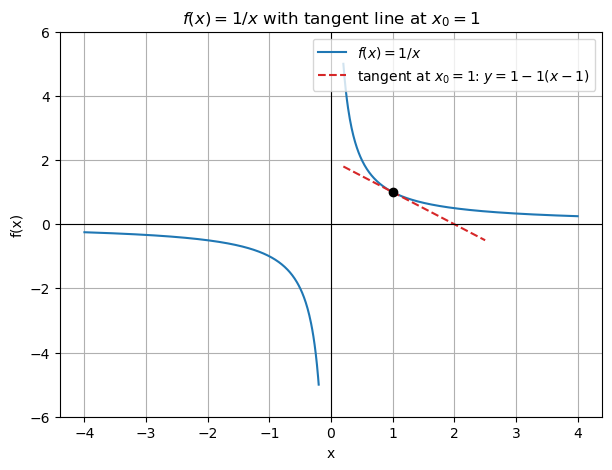

In [3]:
# Graph: f(x) = 1/x with tangent line at x0 = 1
f1_np = sp.lambdify(x, f1, 'numpy')
f1p_np = sp.lambdify(x, f1_prime, 'numpy')

x0 = 1.0
y0 = f1_np(x0)
slope = f1p_np(x0)

xs_right = np.linspace(0.2, 4, 400)
xs_left = np.linspace(-4, -0.2, 400)
xs_tangent = np.linspace(0.2, 2.5, 100)
tangent = y0 + slope * (xs_tangent - x0)

fig, ax = plt.subplots()
ax.plot(xs_right, f1_np(xs_right), color='tab:blue', label='$f(x) = 1/x$')
ax.plot(xs_left, f1_np(xs_left), color='tab:blue')
ax.plot(xs_tangent, tangent, color='tab:red', linestyle='--',
        label=f"tangent at $x_0=1$: $y={y0:.0f}{slope:.0f}(x-1)$")
ax.plot(x0, y0, 'ko', zorder=5)
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_ylim(-6, 6)
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('$f(x) = 1/x$ with tangent line at $x_0 = 1$')
ax.legend()
plt.show()


## ✏️ Worked Example 2: $f(x) = \sqrt{x}$

Same idea, different algebra trick: **rationalize** instead of finding a common denominator.

$$
f'(x) = \lim_{h\to 0} \frac{\sqrt{x+h} - \sqrt{x}}{h}
$$

**Step 1 — multiply by the conjugate** $\dfrac{\sqrt{x+h}+\sqrt{x}}{\sqrt{x+h}+\sqrt{x}}$:

$$
\frac{\sqrt{x+h}-\sqrt{x}}{h}\cdot\frac{\sqrt{x+h}+\sqrt{x}}{\sqrt{x+h}+\sqrt{x}}
= \frac{(x+h) - x}{h\left(\sqrt{x+h}+\sqrt{x}\right)}
= \frac{h}{h\left(\sqrt{x+h}+\sqrt{x}\right)}
$$

**Step 2 — cancel the $h$:**

$$
= \frac{1}{\sqrt{x+h}+\sqrt{x}}
$$

**Step 3 — take the limit** as $h \to 0$:

$$
f'(x) = \frac{1}{\sqrt{x}+\sqrt{x}} = \frac{1}{2\sqrt{x}}
$$

$$
\boxed{f(x) = \sqrt{x} \quad \Longrightarrow \quad f'(x) = \frac{1}{2\sqrt{x}}}
$$

Notice the pattern with Example 1: in both cases the raw difference quotient looks like "0/0" until we do some algebra (common denominator, or rationalizing) to cancel the troublesome $h$ *before* letting it go to zero.


In [4]:
# Symbolic check with sympy
f2 = sp.sqrt(x)
f2_prime = sp.diff(f2, x)
f2_prime  # should simplify to 1/(2*sqrt(x))


1/(2*sqrt(x))

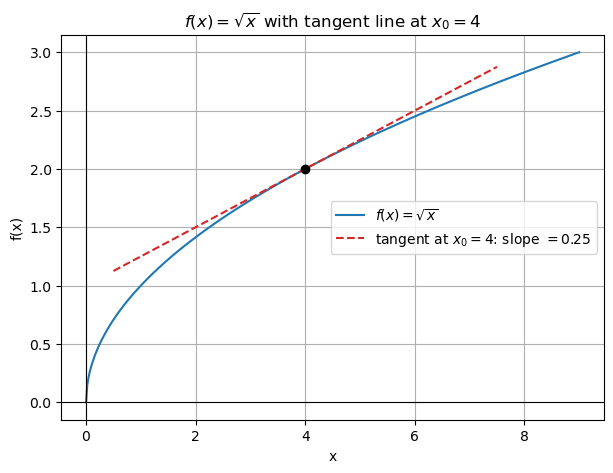

In [5]:
# Graph: f(x) = sqrt(x) with tangent line at x0 = 4
f2_np = sp.lambdify(x, f2, 'numpy')
f2p_np = sp.lambdify(x, f2_prime, 'numpy')

x0 = 4.0
y0 = f2_np(x0)
slope = f2p_np(x0)

xs = np.linspace(0, 9, 400)
xs_tangent = np.linspace(0.5, 7.5, 100)
tangent = y0 + slope * (xs_tangent - x0)

fig, ax = plt.subplots()
ax.plot(xs, f2_np(xs), color='tab:blue', label=r'$f(x) = \sqrt{x}$')
ax.plot(xs_tangent, tangent, color='tab:red', linestyle='--',
        label=f"tangent at $x_0=4$: slope $={slope:.2f}$")
ax.plot(x0, y0, 'ko', zorder=5)
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title(r'$f(x) = \sqrt{x}$ with tangent line at $x_0 = 4$')
ax.legend()
plt.show()


## ✏️ Worked Example 3: Velocity — average vs. instantaneous rate of change

Physical picture: let $y = f(t)$ be the position of an object at time $t$. Take a concrete (illustrative) position function:

$$
f(t) = t^2 \quad (\text{e.g., distance travelled in some unit system})
$$

**Average velocity** between $t_0=1$ and $t_0+\Delta t = 3$ is the slope of the *secant* line:

$$
\bar v = \frac{f(3)-f(1)}{3-1} = \frac{9-1}{2} = 4
$$

**Instantaneous velocity** at $t_0=1$ is the derivative — the slope of the *tangent* line:

$$
v(1) = f'(1) = 2t\Big|_{t=1} = 2
$$

The graph below makes the difference visible: the secant line (average velocity) is steeper than the tangent line (instantaneous velocity at the start of the interval) because the object is speeding up.


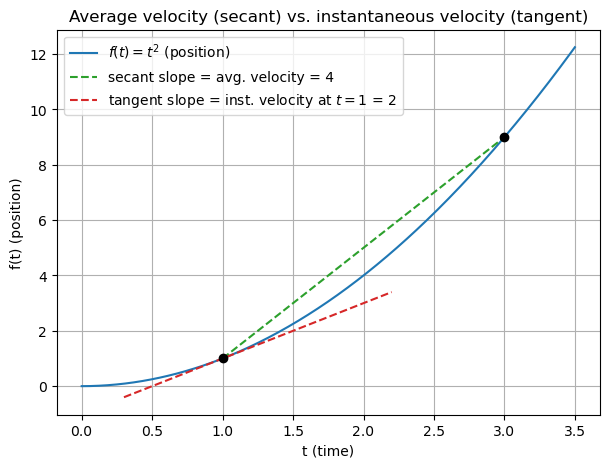

In [6]:
# Graph: position vs time, secant (average velocity) vs tangent (instantaneous velocity)
t = sp.symbols('t')
pos = t**2
pos_np = sp.lambdify(t, pos, 'numpy')
vel_np = sp.lambdify(t, sp.diff(pos, t), 'numpy')

t0, t1 = 1.0, 3.0
y0, y1 = pos_np(t0), pos_np(t1)
avg_v = (y1 - y0) / (t1 - t0)
inst_v = vel_np(t0)

ts = np.linspace(0, 3.5, 400)
ts_secant = np.linspace(t0, t1, 50)
secant = y0 + avg_v * (ts_secant - t0)
ts_tangent = np.linspace(0.3, 2.2, 50)
tangent = y0 + inst_v * (ts_tangent - t0)

fig, ax = plt.subplots()
ax.plot(ts, pos_np(ts), color='tab:blue', label='$f(t) = t^2$ (position)')
ax.plot(ts_secant, secant, color='tab:green', linestyle='--',
        label=f'secant slope = avg. velocity = {avg_v:.0f}')
ax.plot(ts_tangent, tangent, color='tab:red', linestyle='--',
        label=f'tangent slope = inst. velocity at $t=1$ = {inst_v:.0f}')
ax.plot([t0, t1], [y0, y1], 'ko', zorder=5)
ax.set_xlabel('t (time)')
ax.set_ylabel('f(t) (position)')
ax.set_title('Average velocity (secant) vs. instantaneous velocity (tangent)')
ax.legend()
plt.show()


## 🌍 The Big Picture: Two Problems of Calculus

The lecture closes by previewing the whole course. Calculus is built around two problems that turn out to be inverses of each other:

1. **Differentiation** — the tangent line / rate-of-change problem covered today: given $f$, find the slope $f'$ at each point.
2. **Integration** — the area problem (covered later in 18.01): given $f$, find the area under its curve.

The **Fundamental Theorem of Calculus**, proved later in the course, shows these two problems are inverse operations of one another — differentiating "undoes" integrating and vice versa. That connection is the reason calculus is treated as a single unified subject rather than two unrelated topics.


## 🧩 Practice Problems

Work these using the **limit definition** of the derivative — no shortcuts/rules yet, since that's the point of Lecture 1.

1. Let $f(x) = x^2$. Show from the limit definition that $f'(x) = 2x$.
2. Let $f(x) = \dfrac{1}{x^2}$. Find $f'(x)$ from the limit definition.
3. Let $f(x) = \sqrt{x+1}$. Find $f'(x)$ from the limit definition (rationalize).
4. A ball's height is $h(t) = 20t - 5t^2$ (meters, seconds). Find the *average* velocity on $[0,2]$ and the *instantaneous* velocity at $t=0$.
5. Write the equation of the tangent line to $f(x)=1/x$ at $x_0 = 2$.

Use the code cell below to check your algebra against sympy once you've worked it by hand.


In [7]:
# Practice-problem checker — verify your by-hand derivatives here
# Example usage: fill in expr and compare to your hand-worked answer.

expr = x**2  # <- replace with the function from the problem you're checking
sp.diff(expr, x)


2*x

## 🔑 Summary / Key Takeaways

- The derivative $f'(x_0)$ has **two equivalent meanings**: the slope of the tangent line to $y=f(x)$ at $x_0$ (geometric), and the instantaneous rate of change of $f$ (physical — velocity when $f$ is position).
- It's defined as a **limit of a difference quotient**: $f'(x_0) = \lim_{h\to 0} \dfrac{f(x_0+h)-f(x_0)}{h}$.
- Computing it from the definition almost always requires an **algebraic trick** first (common denominator, rationalizing, factoring) to cancel the $h$ before taking the limit — otherwise you're stuck with $0/0$.
- **Average rate of change** (secant slope) ≠ **instantaneous rate of change** (tangent slope) — the whole point of the limit is to shrink the interval to a single point.
- Calculus has two big problems — differentiation (today) and integration (later) — connected by the Fundamental Theorem of Calculus.

**Still confused about:** ...
**Next lecture:** Lecture 2 — Limits, Continuity, and Trigonometric Limits
